In [1]:
# 0. CARGA DEL DATA SAMPLE PARA REPRODUCIBILIDAD
# -------------------------------------------------------------

import pandas as pd

# Cargar el dataset de muestra
df = pd.read_parquet("src/data_sample/air_quality_sample.parquet")

df.head()

,Samplingpoint,Pollutant,Start,End,Value,Unit,AggType,Validity,Verification,ResultTime,DataCapture,FkObservationLog
0,ES/SP_41091016_10_49,5,2022-09-28 20:00:00,2022-09-28 21:00:00,44.690000000000000000,ug.m-3,hour,1,1,2023-07-09 19:16:00,None,324d40d7-9da8-4656-b5f4-1749dcdf2897
1,ES/SP_28079056_9_47,6001,2022-03-14 19:00:00,2022-03-14 20:00:00,10.000000000000000000,ug.m-3,hour,1,1,2023-07-09 20:30:00,None,865e265a-b481-45bd-a672-b9668c1d869c
2,ES/SP_28079058_14_6,7,2024-07-12 12:00:00,2024-07-12 13:00:00,134.000000000000000000,ug.m-3,hour,1,1,2025-06-19 17:46:00,None,07046feb-667e-4655-a32e-92fc0221af68
3,ES/SP_28074007_9_49,6001,2022-09-04 09:00:00,2022-09-04 10:00:00,7.000000000000000000,ug.m-3,hour,1,1,2023-07-09 20:29:00,None,a43ce98a-25f1-4415-8aa9-bac573de2db1
4,ES/SP_48902006_9_49,6001,2023-12-04 09:00:00,2023-12-04 10:00:00,1.000000000000000000,ug.m-3,hour,1,1,2024-08-02 10:44:00,None,2e105f1f-d0a9-4dfd-afec-aacb47c3a543


In [2]:
df.shape #Comprobación del tamaño del dataset

(5000, 12)

In [3]:
# 2. PREPROCESADO INICIAL: creación de fecha, mapeo de contaminantes y pivotado

# -------------------------------------------------------------
# 1) Crear columna de fecha a partir de 'Start'
# -------------------------------------------------------------

# Convertimos la columna Start a tipo datetime
df["Fecha"] = pd.to_datetime(df["Start"])

# Mostramos las primeras filas para comprobar
df[["Start", "Fecha"]].head()

,Start,Fecha
0,2022-09-28 20:00:00,2022-09-28 20:00:00
1,2022-03-14 19:00:00,2022-03-14 19:00:00
2,2024-07-12 12:00:00,2024-07-12 12:00:00
3,2022-09-04 09:00:00,2022-09-04 09:00:00
4,2023-12-04 09:00:00,2023-12-04 09:00:00


In [4]:
# -------------------------------------------------------------
# 2) Mapear códigos de contaminantes a nombres reales
# -------------------------------------------------------------

# Diccionario oficial de códigos EEA
mapa_contaminantes = {
    5: "PM10",
    6001: "PM25",
    8: "NO2",
    7: "O3"
}

# Creamos una nueva columna con el nombre del contaminante
df["Contaminante"] = df["Pollutant"].map(mapa_contaminantes)

# Comprobamos que se ha creado correctamente
df[["Pollutant", "Contaminante"]].head()

,Pollutant,Contaminante
0,5,PM10
1,6001,PM25
2,7,O3
3,6001,PM25
4,6001,PM25


In [5]:
df["Pollutant"].unique() # Comprobamos que solo tenemos los contaminantes esperados
# El dataset contiene códigos oficiales de la Agencia Europea de Medio Ambiente (EEA) para los contaminantes PM10, PM2.5, NO2 y O3. El mapeo ha funcionado correctamente.


array([   5, 6001,    7,    8], dtype=int32)

In [6]:
df["Contaminante"].unique() # Comprobamos que el mapeo ha funcionado

array(['PM10', 'PM25', 'O3', 'NO2'], dtype=object)

In [7]:
# -------------------------------------------------------------
# 3) Pivotar contaminantes para tener columnas PM10, PM25, NO2, O3 
# (pasar de formato largo a ancho)
# -------------------------------------------------------------

df_pivot = df.pivot_table(
    index=["Samplingpoint", "Fecha"],   # agrupamos por estación y fecha
    columns="Contaminante",            # cada contaminante será una columna
    values="Value"                     # valores medidos
).reset_index()

# Mostramos el resultado
df_pivot.head()

Contaminante,Samplingpoint,Fecha,NO2,O3,PM10,PM25
0,ES/SP_06015001_14_6,2022-02-22 08:00:00,NaN,6.1,NaN,NaN
1,ES/SP_06015001_14_6,2022-06-07 12:00:00,NaN,60.0,NaN,NaN
2,ES/SP_06015001_14_6,2022-07-07 09:00:00,NaN,89.0,NaN,NaN
3,ES/SP_06015001_14_6,2022-10-18 23:00:00,NaN,60.0,NaN,NaN
4,ES/SP_06015001_14_6,2022-11-09 03:00:00,NaN,40.0,NaN,NaN


In [8]:
# -------------------------------------------------------------
# Comprobación adicional: número de registros por contaminante
# -------------------------------------------------------------
# Tras el pivotado, 'Contaminante' ya no es una columna.
# Por eso comprobamos directamente las columnas PM10, PM25, NO2 y O3.
# Esto permite verificar si algún contaminante tiene muy pocos datos

df_pivot[["PM10", "PM25", "NO2", "O3"]].count()

Contaminante
PM10    1046
PM25     689
NO2     1962
O3      1303
dtype: int64

In [9]:
# -------------------------------------------------------------
# 4) Ordenar por fecha 
# -------------------------------------------------------------

df_pivot = df_pivot.sort_values("Fecha")
df_pivot.head()

Contaminante,Samplingpoint,Fecha,NO2,O3,PM10,PM25
900,ES/SP_08301004_8_8,2022-01-01 01:00:00,31.0,NaN,NaN,NaN
2699,ES/SP_28079060_14_6,2022-01-01 02:00:00,NaN,7.25,NaN,NaN
3421,ES/SP_41091019_14_6,2022-01-01 08:00:00,NaN,18.0,NaN,NaN
4633,ES/SP_48020062_8_8,2022-01-01 14:00:00,9.0,NaN,NaN,NaN
1163,ES/SP_28058004_10_49,2022-01-01 15:00:00,NaN,NaN,6.0,NaN


In [10]:
# 3. INTEGRACIÓN POR CIUDAD: unificar estaciones

# -------------------------------------------------------------
# 3.1. Asignación automática de ciudad según el prefijo del código de estación
# -------------------------------------------------------------

def asignar_ciudad(codigo):
    if codigo.startswith("ES/SP_060"):
        return "Badajoz"
    if codigo.startswith("ES/SP_280"):
        return "Madrid"
    if codigo.startswith("ES/SP_462"):
        return "Valencia"
    if codigo.startswith("ES/SP_480"):
        return "Bilbao"
    if codigo.startswith("ES/SP_410"):
        return "Sevilla"
    if codigo.startswith("ES/SP_08"):   # incluye 080, 081, 082, 083
        return "Barcelona"  # por si aparece algo raro
    return None

# Aplicar la función para crear la columna Ciudad
df_pivot["Ciudad"] = df_pivot["Samplingpoint"].apply(asignar_ciudad)
df_pivot[["Samplingpoint", "Ciudad"]].head()


Contaminante,Samplingpoint,Ciudad
900,ES/SP_08301004_8_8,Barcelona
2699,ES/SP_28079060_14_6,Madrid
3421,ES/SP_41091019_14_6,Sevilla
4633,ES/SP_48020062_8_8,Bilbao
1163,ES/SP_28058004_10_49,Madrid


In [11]:
# -------------------------------------------------------------
# 3.2. Reordenar columnas para mayor claridad
# -------------------------------------------------------------
# Después de asignar la ciudad, queremos que el DataFrame tenga
# un orden lógico y fácil de leer:
#   1) Ciudad
#   2) Código de estación
#   3) Fecha completa (con hora)
#   4) Contaminantes ya pivotados
#
# Esto NO modifica datos, solo cambia el orden visual de columnas.

df_pivot = df_pivot[[
    "Ciudad",          # Ciudad asignada automáticamente
    "Samplingpoint",   # Código de estación original
    "Fecha",           # Fecha y hora de la medición
    "PM10", "PM25",    # Partículas
    "NO2", "O3"        # Gases
]]

# Vista rápida para confirmar que el orden es correcto
df_pivot.head()

Contaminante,Ciudad,Samplingpoint,Fecha,PM10,PM25,NO2,O3
900,Barcelona,ES/SP_08301004_8_8,2022-01-01 01:00:00,NaN,NaN,31.0,NaN
2699,Madrid,ES/SP_28079060_14_6,2022-01-01 02:00:00,NaN,NaN,NaN,7.25
3421,Sevilla,ES/SP_41091019_14_6,2022-01-01 08:00:00,NaN,NaN,NaN,18.0
4633,Bilbao,ES/SP_48020062_8_8,2022-01-01 14:00:00,NaN,NaN,9.0,NaN
1163,Madrid,ES/SP_28058004_10_49,2022-01-01 15:00:00,6.0,NaN,NaN,NaN


In [12]:
# -------------------------------------------------------------
# 3.3. Crear fecha diaria (sin hora)
# -------------------------------------------------------------
# La columna 'Fecha' contiene fecha y hora (ej: 2023-01-01 13:00)
# Para obtener medias diarias necesitamos una fecha sin hora.
# .dt.date extrae solo la parte de fecha (YYYY-MM-DD)

df_pivot["Fecha_dia"] = df_pivot["Fecha"].dt.date

# Comprobación rápida
df_pivot[["Fecha", "Fecha_dia"]].head()


Contaminante,Fecha,Fecha_dia
900,2022-01-01 01:00:00,2022-01-01
2699,2022-01-01 02:00:00,2022-01-01
3421,2022-01-01 08:00:00,2022-01-01
4633,2022-01-01 14:00:00,2022-01-01
1163,2022-01-01 15:00:00,2022-01-01


In [ ]:
# -------------------------------------------------------------
# 3.4. Agrupar por ciudad y día (media diaria de contaminantes)
# -------------------------------------------------------------

# Calcular la media diaria por ciudad
df_ciudad = (
    df_pivot
    .groupby(["Ciudad", "Fecha_dia"])[["PM10", "PM25", "NO2", "O3"]]
    .mean()
    .reset_index()
)

# Vista rápida del resultado
df_ciudad.head()

Contaminante,Ciudad,Fecha_dia,PM10,PM25,NO2,O3
0,Badajoz,2022-01-11,NaN,NaN,9.4,NaN
1,Badajoz,2022-01-31,NaN,NaN,49.0,NaN
2,Badajoz,2022-02-22,NaN,NaN,NaN,6.1
3,Badajoz,2022-05-14,NaN,NaN,10.0,NaN
4,Badajoz,2022-06-07,NaN,NaN,NaN,60.0


In [14]:
# 4. LIMPIEZA DE DATOS: valores nulos, valores anómalos, outliers, consistencia
# Comprobar dataframe
df_ciudad.head()
# Columnas esperadas:Ciudad | Fecha_dia | PM10 | PM25 | NO2 | O3

Contaminante,Ciudad,Fecha_dia,PM10,PM25,NO2,O3
0,Badajoz,2022-01-11,NaN,NaN,9.4,NaN
1,Badajoz,2022-01-31,NaN,NaN,49.0,NaN
2,Badajoz,2022-02-22,NaN,NaN,NaN,6.1
3,Badajoz,2022-05-14,NaN,NaN,10.0,NaN
4,Badajoz,2022-06-07,NaN,NaN,NaN,60.0


In [15]:
# Lista de columnas de contaminantes
cols_contam = ["PM10", "PM25", "NO2", "O3"]

In [16]:
# -------------------------------------------------------------
# 4.1. Asegurar tipos correctos antes de limpiar.
# -------------------------------------------------------------

#FORZAR conversion a float de los contaminantes.
# Los contaminantes deben ser numéricos para poder interpolar.
# Algunos valores pueden venir como strings, con comas, espacios, etc.
# Esta celda limpia y convierte todo a float.

import numpy as np

for c in cols_contam:
    df_ciudad[c] = (
        df_ciudad[c]
        .astype(str)           # convertir todo a string
        .str.replace(",", ".") # cambiar coma decimal por punto
        .str.strip()           # quitar espacios
        .replace(["", " ", "--", "None", "nan", "NaN"], np.nan)
    )
    df_ciudad[c] = pd.to_numeric(df_ciudad[c], errors="coerce")

df_ciudad[cols_contam].dtypes

Contaminante
PM10    float64
PM25    float64
NO2     float64
O3      float64
dtype: object

In [17]:
# -------------------------------------------------------------
# 4.2. Comprobación de valores nulos
# -------------------------------------------------------------

# Ver número de valores nulos por columna
df_ciudad.isna().sum()

Contaminante
Ciudad          0
Fecha_dia       0
PM10         2109
PM25         2379
NO2          1468
O3           1918
dtype: int64

In [18]:
# Ver solo nulos en las columnas numericas (contaminantes)
df_ciudad[["PM10", "PM25", "NO2", "O3"]].isna().sum()

Contaminante
PM10    2109
PM25    2379
NO2     1468
O3      1918
dtype: int64

In [19]:
df_ciudad[cols_contam].isna().sum()

Contaminante
PM10    2109
PM25    2379
NO2     1468
O3      1918
dtype: int64

In [20]:
# -------------------------------------------------------------
# 4.3. Tratar valores especiales: sustituir valores -999 por NaN en contaminantes
# -------------------------------------------------------------

import numpy as np

# Reemplazar -999 por NaN en cada contaminante
for c in cols_contam:
    # Donde el valor sea -999, poner NaN
    df_ciudad.loc[df_ciudad[c] == -999, c] = np.nan

In [21]:
# Comprobar cuántos NaN hay ahora en cada contaminante
df_ciudad[cols_contam].isna().sum()

Contaminante
PM10    2143
PM25    2424
NO2     1512
O3      1947
dtype: int64

In [22]:
df_ciudad.dtypes

Contaminante
Ciudad        object
Fecha_dia     object
PM10         float64
PM25         float64
NO2          float64
O3           float64
dtype: object

In [23]:
# -------------------------------------------------------------
# 4.3.1. Eliminar valores negativos antes de interpolar
# -------------------------------------------------------------
# En contaminación atmosférica NO existen valores negativos.
# Si aparecen, son errores de medición o valores corruptos.
# Los convertimos a NaN para que la interpolación los repare.

for c in cols_contam:
    df_ciudad.loc[df_ciudad[c] < 0, c] = np.nan

In [24]:
# -------------------------------------------------------------
# 4.4. Interpolación de valores faltantes por ciudad
# -------------------------------------------------------------
# Problema original: Pandas no puede interpolar si hay columnas tipo object
# dentro del groupby. La solución es:
#   1) Asegurar que Fecha_dia es datetime
#   2) Ordenar por ciudad y fecha
#   3) Interpolar SOLO las columnas numéricas (contaminantes)
#   4) Limpiar el índice del groupby

# 1) Asegurar que Fecha_dia es datetime
df_ciudad["Fecha_dia"] = pd.to_datetime(df_ciudad["Fecha_dia"])

# 2) Ordenar antes de interpolar
df_ciudad = df_ciudad.sort_values(["Ciudad", "Fecha_dia"])

# 3) Interpolar solo columnas numéricas, por ciudad
df_ciudad[cols_contam] = (
    df_ciudad
    .groupby("Ciudad")[cols_contam]
    .apply(lambda g: g.interpolate(method="linear", limit_direction="both"))
    .reset_index(level=0, drop=True)   # evita problemas de índice
)

# 4) Comprobación final de nulos
df_ciudad[cols_contam].isna().sum()

Contaminante
PM10    41
PM25    41
NO2      0
O3       0
dtype: int64

In [25]:
# -------------------------------------------------------------
# 4.5. Detección de outliers con IQR (por contaminante)
# -------------------------------------------------------------

def marcar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    return (serie < lim_inf) | (serie > lim_sup)

# Crear columnas de outliers
for c in cols_contam:
    df_ciudad[f"{c}_outlier"] = marcar_outliers_iqr(df_ciudad[c])

# Eliminar filas donde haya outliers en cualquiera de los contaminantes

# Fila marcada como outlier si CUALQUIER contaminante lo es
mask_out = df_ciudad[[f"{c}_outlier" for c in cols_contam]].any(axis=1)

# Crear dataset limpio
df_ciudad_sin_outliers = df_ciudad.loc[~mask_out].copy()


In [26]:
# -------------------------------------------------------------
# 4.6. Comprobación final del dataset limpio
# -------------------------------------------------------------

# Queremos revisar tres cosas:
#   1) Primeras filas del dataset final (para ver estructura)
#   2) Estadísticas descriptivas de los contaminantes
#   3) Número de registros por ciudad tras eliminar outliers
#
# Usamos display() para que Jupyter muestre los tres outputs
# en la misma celda, en lugar de solo el último.

from IPython.display import display

# 1) Vista rápida del dataset final
display(df_ciudad_sin_outliers[["Ciudad", "Fecha_dia"] + cols_contam].head())

# 2) Estadísticas descriptivas de los contaminantes
display(df_ciudad_sin_outliers[cols_contam].describe())

# 3) Conteo de registros por ciudad
display(df_ciudad_sin_outliers["Ciudad"].value_counts())

Contaminante,Ciudad,Fecha_dia,PM10,PM25,NO2,O3
0,Badajoz,2022-01-11,NaN,NaN,9.400000,6.10
1,Badajoz,2022-01-31,NaN,NaN,49.000000,6.10
2,Badajoz,2022-02-22,NaN,NaN,29.500000,6.10
3,Badajoz,2022-05-14,NaN,NaN,10.000000,33.05
4,Badajoz,2022-06-07,NaN,NaN,9.366667,60.00


Contaminante,PM10,PM25,NO2,O3
count,2547.000000,2547.000000,2588.000000,2588.000000
mean,18.533593,8.766739,19.127099,55.579349
std,9.195904,4.350989,12.617864,25.968945
min,1.000000,0.000000,1.000000,1.000000
25%,12.000000,5.690000,9.500000,36.825000
50%,17.250000,8.470391,15.666667,56.000000
75%,24.240385,11.418788,26.198864,74.000000
max,45.000000,21.450000,55.000000,131.800000


Ciudad
Madrid       746
Barcelona    564
Bilbao       453
Valencia     448
Sevilla      336
Badajoz       41
Name: count, dtype: int64

In [27]:
# Comprobación adicional: estadísticas descriptivas de contaminantes tras eliminar outliers

df_ciudad_sin_outliers[cols_contam].describe()

Contaminante,PM10,PM25,NO2,O3
count,2547.000000,2547.000000,2588.000000,2588.000000
mean,18.533593,8.766739,19.127099,55.579349
std,9.195904,4.350989,12.617864,25.968945
min,1.000000,0.000000,1.000000,1.000000
25%,12.000000,5.690000,9.500000,36.825000
50%,17.250000,8.470391,15.666667,56.000000
75%,24.240385,11.418788,26.198864,74.000000
max,45.000000,21.450000,55.000000,131.800000


In [28]:
# Comprobación adicional: número total de registros tras eliminar outliers

len(df_ciudad_sin_outliers)

2588

In [29]:
# Comprobación adicional: verificar si ambos dataframes apuntan al mismo objeto en memoria.
# df_ciudad es el dataframe antes de eliminar outliers
# df_ciudad_sin_outliers es una copia filtrada sin outliers

df_ciudad_sin_outliers is df_ciudad

False

In [30]:
# -------------------------------------------------------------
# 4.7. Verificación final tras interpolación y limpieza
# -------------------------------------------------------------

print("Valores nulos por contaminante:")
display(df_ciudad_sin_outliers[cols_contam].isna().sum())

print("\nEstadísticas descriptivas finales:")
display(df_ciudad_sin_outliers[cols_contam].describe())

print("\nCorrelación entre contaminantes (dataset limpio):")
display(df_ciudad_sin_outliers[cols_contam].corr())

# Comprobación visual rápida de rangos
print("\nRangos por contaminante:")
for c in cols_contam:
    print(f"{c}: min={df_ciudad_sin_outliers[c].min()}, max={df_ciudad_sin_outliers[c].max()}")

Valores nulos por contaminante:


Contaminante
PM10    41
PM25    41
NO2      0
O3       0
dtype: int64


Estadísticas descriptivas finales:


Contaminante,PM10,PM25,NO2,O3
count,2547.000000,2547.000000,2588.000000,2588.000000
mean,18.533593,8.766739,19.127099,55.579349
std,9.195904,4.350989,12.617864,25.968945
min,1.000000,0.000000,1.000000,1.000000
25%,12.000000,5.690000,9.500000,36.825000
50%,17.250000,8.470391,15.666667,56.000000
75%,24.240385,11.418788,26.198864,74.000000
max,45.000000,21.450000,55.000000,131.800000



Correlación entre contaminantes (dataset limpio):


Contaminante,PM10,PM25,NO2,O3
Contaminante,,,,
PM10,1.000000,0.173885,0.049324,0.105345
PM25,0.173885,1.000000,0.085651,-0.069211
NO2,0.049324,0.085651,1.000000,-0.144847
O3,0.105345,-0.069211,-0.144847,1.000000



Rangos por contaminante:
PM10: min=1.0, max=45.0
PM25: min=0.0, max=21.449999999999996
NO2: min=1.0, max=55.0
O3: min=1.0, max=131.8


In [31]:
# ---------------------------------------------------------------------
# 4.8. Guardar dataset limpio para reutilizarlo sin repetir el pipeline
# ---------------------------------------------------------------------

# Guardar en formato Parquet (recomendado: más rápido y eficiente)
df_ciudad_sin_outliers.to_parquet("src/otros_data/air_quality_clean.parquet", index=False)

# Opcional: guardar también en CSV
df_ciudad_sin_outliers.to_csv("src/otros_data/air_quality_clean.csv", index=False)

print("Dataset limpio guardado correctamente.")

Dataset limpio guardado correctamente.


In [32]:
# =============================================================
# 5. FEATURE ENGINEERING (mes, estación del año, tendencias, etc.)
# =============================================================

# En este apartado creamos nuevas variables temporales y derivadas 
# que enriquecen el dataset para análisis, clustering y regresión.
# Partimos del dataset limpio: df_ciudad_sin_outliers

df_feat = df_ciudad_sin_outliers.copy()

In [33]:
# -------------------------------------------------------------
# 5.1. Convertir Fecha_dia a datetime
# -------------------------------------------------------------

# Aseguramos que la columna Fecha_dia está en formato fecha real.
# Esto permite extraer componentes temporales sin errores.

df_feat["Fecha_dia"] = pd.to_datetime(df_feat["Fecha_dia"], errors="coerce")

In [34]:
# -------------------------------------------------------------
# 5.2. Extraer componentes temporales
# -------------------------------------------------------------

# Creamos variables temporales útiles para análisis estacional y para modelos predictivos.

df_feat["Año"] = df_feat["Fecha_dia"].dt.year
df_feat["Mes"] = df_feat["Fecha_dia"].dt.month
df_feat["Día"] = df_feat["Fecha_dia"].dt.day
df_feat["Día_semana"] = df_feat["Fecha_dia"].dt.weekday  # 0=lunes, 6=domingo
df_feat["Semana_año"] = df_feat["Fecha_dia"].dt.isocalendar().week.astype(int)

In [35]:
# -------------------------------------------------------------
# 5.3. Estación del año
# -------------------------------------------------------------

# Clasificamos cada fecha en su estación correspondiente.

def estacion_del_año(mes):
    if mes in [12, 1, 2]:
        return "Invierno"
    elif mes in [3, 4, 5]:
        return "Primavera"
    elif mes in [6, 7, 8]:
        return "Verano"
    else:
        return "Otoño"

df_feat["Estacion"] = df_feat["Mes"].apply(estacion_del_año)

In [36]:
# -------------------------------------------------------------
# 5.3.1. Tendencia acumulada (cumulative sum)
# -------------------------------------------------------------

# Esta variable captura la evolución acumulada del PM10 por ciudad.
# Es útil para modelos que detectan tendencias a largo plazo.
# Ayuda a modelos como Random Forest, XGBoost o regresiones a entender si una ciudad está acumulando más contaminación con el tiempo
# Feature muy usada en series temporales cuando no se quiere diferenciar explícitamente la estacionalidad

df_feat["PM10_cumsum"] = df_feat.groupby("Ciudad")["PM10"].cumsum()

In [37]:
# -------------------------------------------------------------
# 5.4. Tendencias (rolling windows)
# -------------------------------------------------------------

# Calculamos la media móvil de 7 días por contaminante.
# Esto suaviza la serie y captura tendencias a corto plazo.

for c in cols_contam:
    df_feat[f"{c}_roll7"] = (
        df_feat.groupby("Ciudad")[c]
        .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
    )

In [38]:
# -------------------------------------------------------------
# 5.5. Variables rezagadas (lags)
# -------------------------------------------------------------

# Creamos el valor del día anterior (lag 1) para cada contaminante.
# Esto es clave para modelos predictivos basados en series temporales.

for c in cols_contam:
    df_feat[f"{c}_lag1"] = (
        df_feat.groupby("Ciudad")[c].shift(1)
    )

In [39]:
# -------------------------------------------------------------
# 5.6. Diferencias día a día
# -------------------------------------------------------------

# Calculamos la diferencia respecto al día anterior.
# Captura cambios bruscos y variabilidad diaria.

for c in cols_contam:
    df_feat[f"{c}_diff"] = (
        df_feat.groupby("Ciudad")[c].diff()
    )

In [40]:
# -------------------------------------------------------------
# 5.7. Comprobación final
# -------------------------------------------------------------

# Mostramos las primeras filas para verificar que las nuevas variables se han creado correctamente.
df_feat.head()

Contaminante,Ciudad,Fecha_dia,PM10,PM25,NO2,O3,PM10_outlier,PM25_outlier,NO2_outlier,O3_outlier,...,NO2_roll7,O3_roll7,PM10_lag1,PM25_lag1,NO2_lag1,O3_lag1,PM10_diff,PM25_diff,NO2_diff,O3_diff
0,Badajoz,2022-01-11,NaN,NaN,9.400000,6.10,False,False,False,False,...,9.400000,6.1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Badajoz,2022-01-31,NaN,NaN,49.000000,6.10,False,False,False,False,...,29.200000,6.1000,NaN,NaN,9.4,6.10,NaN,NaN,39.600000,0.00
2,Badajoz,2022-02-22,NaN,NaN,29.500000,6.10,False,False,False,False,...,29.300000,6.1000,NaN,NaN,49.0,6.10,NaN,NaN,-19.500000,0.00
3,Badajoz,2022-05-14,NaN,NaN,10.000000,33.05,False,False,False,False,...,24.475000,12.8375,NaN,NaN,29.5,6.10,NaN,NaN,-19.500000,26.95
4,Badajoz,2022-06-07,NaN,NaN,9.366667,60.00,False,False,False,False,...,21.453333,22.2700,NaN,NaN,10.0,33.05,NaN,NaN,-0.633333,26.95


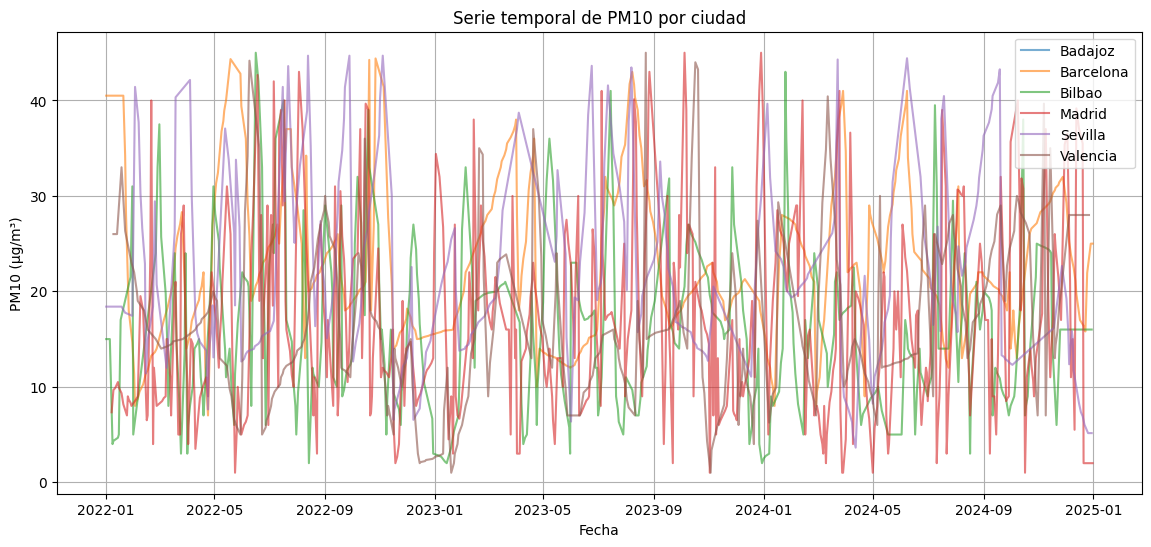

In [41]:
# =============================================================
# 6. MINI‑EDA (Análisis Exploratorio de Datos)
# =============================================================

# 6.1. MINI-EDA:Serie temporal de PM10 por ciudad

import matplotlib.pyplot as plt
import matplotlib as mpl

# Este gráfico permite visualizar la evolución del PM10 a lo largo del tiempo.
# Es fundamental para detectar tendencias, estacionalidad, picos y anomalías.
# Además, justifica la creación de variables lag y diff en el preprocesado.


# Filtramos solo PM10
df_pm10 = df[df['Contaminante'] == 'PM10']

# Evitar overflow con muchas líneas
mpl.rcParams['agg.path.chunksize'] = 10000

plt.figure(figsize=(14,6))

for ciudad in df_ciudad_sin_outliers["Ciudad"].unique():
    df_c = df_ciudad_sin_outliers[df_ciudad_sin_outliers["Ciudad"] == ciudad]
    plt.plot(df_c["Fecha_dia"], df_c["PM10"], alpha=0.6, label=ciudad)

plt.title("Serie temporal de PM10 por ciudad")
plt.xlabel("Fecha")
plt.ylabel("PM10 (µg/m³)")
plt.legend()
plt.grid(True)

plt.savefig("src/img/serie_temporal_pm10.png", dpi=300, bbox_inches="tight")
plt.show()

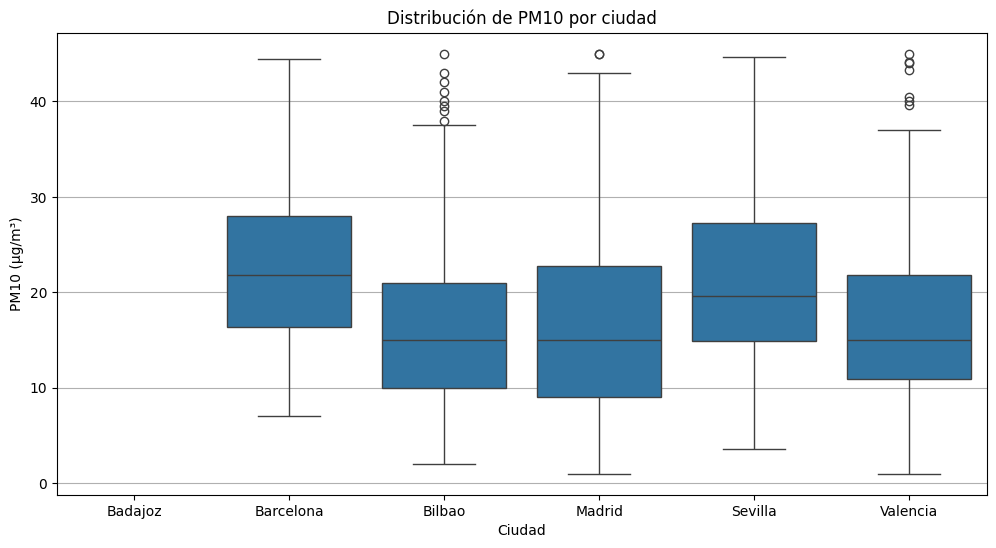

In [42]:
# 6.2. MINI‑EDA: Boxplot de PM10 por ciudad

import seaborn as sns

# Boxplot con seaborn (NO pandas)

# Este boxplot permite comparar la distribución del PM10 entre ciudades.
# Ayuda a identificar ciudades con niveles más altos o más variables.
# También permite detectar outliers y diferencias estructurales entre zonas.

plt.figure(figsize=(12,6))
sns.boxplot(data=df_ciudad_sin_outliers, x="Ciudad", y="PM10")
plt.title("Distribución de PM10 por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("PM10 (µg/m³)")
plt.grid(True, axis='y')

plt.savefig("src/img/boxplot_pm10_ciudad.png", dpi=300, bbox_inches="tight")
plt.show()


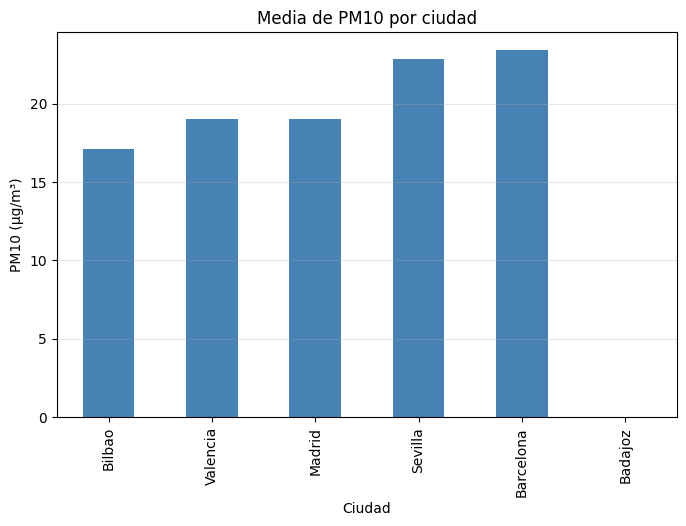

In [43]:
# 6.3. MINI‑EDA: Gráfico de barras

# Nos ayuda a realizar la comparación entre ciudades.

import matplotlib.pyplot as plt

# Calcular la media de PM10 por ciudad usando df_ciudad
media_pm10 = df_ciudad.groupby("Ciudad")["PM10"].mean().sort_values()

# Gráfico de barras
plt.figure(figsize=(8,5))
media_pm10.plot(kind="bar", color="steelblue")

plt.title("Media de PM10 por ciudad")
plt.ylabel("PM10 (µg/m³)")
plt.xlabel("Ciudad")
plt.grid(axis="y", alpha=0.3)

# Guardar imagen
plt.savefig("src/img/media_pm10_por_ciudad.png", dpi=300, bbox_inches="tight")
plt.show()

In [44]:
# Verificar si Badajoz tiene datos de PM10

df_ciudad.groupby("Ciudad")["PM10"].count() # Muestra cuántos registros tiene cada ciudad.

Ciudad
Badajoz        0
Barcelona    604
Bilbao       484
Madrid       909
Sevilla      418
Valencia     508
Name: PM10, dtype: int64

Se comprueba que Badajoz no tiene datos de PM10 en el dataframe df_ciudad.

In [45]:
# Comprobar que Badajoz aparece en df_ciudad

df_ciudad["Ciudad"].unique()

array(['Badajoz', 'Barcelona', 'Bilbao', 'Madrid', 'Sevilla', 'Valencia'],
      dtype=object)

Como Badajoz sí aparece en el df, entonces el problema está en los valores de PM10 (todos nulos o inexistentes).

In [46]:
# Ver cuántos registros tiene Badajoz

df_ciudad[df_ciudad["Ciudad"] == "Badajoz"].shape # Muestra el número de filas y columnas que hay para Badajoz. 
#Si es 0, no hay datos. Si es > 0, sí hay datos.

(41, 10)

In [47]:
# Ver si Badajoz tiene valores de PM10

df_ciudad[df_ciudad["Ciudad"] == "Badajoz"]["PM10"].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: PM10, dtype: float64

Badajoz si tiene filas en df_ciudad (41 filas), pero no existe ningún dato de PM10 para Badajoz en tu dataset, al menos en el periodo analizado. Puede ocurrir porque la estación de Badajoz no reporte PM10 (algunas estaciones de España reportan solo determinados contaminantes).

In [48]:
df_ciudad[df_ciudad["Ciudad"] == "Badajoz"]["PM10"].isna().sum()

np.int64(41)

In [49]:
# Comprobar si Badajoz tiene otros contaminantes

df_ciudad[df_ciudad["Ciudad"] == "Badajoz"][["PM25", "NO2", "O3"]].count()

Contaminante
PM25     0
NO2     41
O3      41
dtype: int64

Las estaciones de Badajoz solo reportan NO₂ y O₃ en tu dataset. No reportan PM10 ni PM2.5.

Esto es completamente normal en datos reales de calidad del aire, ya que muchas estaciones españolas no miden todos los contaminantes.

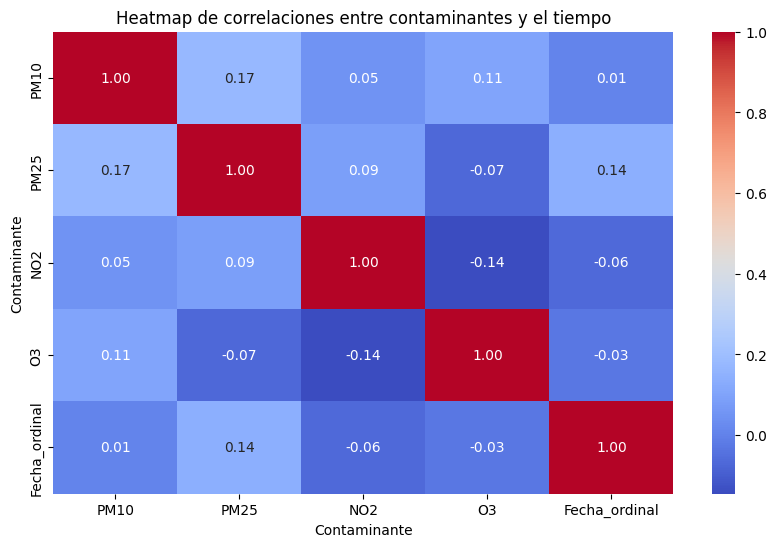

In [50]:
# 6.4. MINI‑EDA: Heatmap de correlaciones (dataset limpio por ciudad)

# Este heatmap permite visualizar la relación entre variables numéricas.
# Ayuda a identificar correlaciones relevantes para el modelado.
# También permite detectar multicolinealidad entre features.

import seaborn as sns
import matplotlib.pyplot as plt

# Copia del dataset limpio
df_corr = df_ciudad_sin_outliers.copy()

# Convertimos la fecha a número para poder correlacionarla
df_corr["Fecha_ordinal"] = df_corr["Fecha_dia"].map(lambda x: x.toordinal())

# Seleccionamos solo columnas numéricas relevantes
cols = ["PM10", "PM25", "NO2", "O3", "Fecha_ordinal"]

# Calculamos la matriz de correlación
corr = df_corr[cols].corr()

# Dibujamos el heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap de correlaciones entre contaminantes y el tiempo")
plt.savefig("src/img/heatmap_correlacion.png", dpi=300, bbox_inches="tight")
plt.show()

In [51]:
# =============================================================
# 7. PREPARACIÓN DEL DATASET PARA CLUSTERING Y REGRESIÓN
# =============================================================

# Partimos del dataset enriquecido: df_feat
# En este punto:
#   - Seleccionamos variables relevantes
#   - Codificamos variables categóricas
#   - Escalamos características numéricas
#   - Creamos dataset para clustering
#   - Creamos dataset para regresión
#   - Dividimos en train/test

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [52]:
# -------------------------------------------------------------
# 7.1. Selección de columnas numéricas para clustering
# -------------------------------------------------------------
#
#  Usamos solo variables numéricas que describen contaminación
# y sus transformaciones. NO incluimos la fecha ni la ciudad.

cols_numericas = [
    "PM10", "PM25", "NO2", "O3",
    "PM10_roll7", "PM25_roll7", "NO2_roll7", "O3_roll7",
    "PM10_lag1", "PM25_lag1", "NO2_lag1", "O3_lag1",
    "PM10_diff", "PM25_diff", "NO2_diff", "O3_diff"
]

# Dataset para clustering
df_cluster = df_feat[cols_numericas].copy()

In [53]:
# -------------------------------------------------------------
# 7.2. Escalado para clustering (ELIMINANDO NaNs)
# -------------------------------------------------------------

# Eliminamos filas con NaN generados por lag1 y diff
df_cluster = df_cluster.dropna()

# El clustering (KMeans, DBSCAN, etc.) requiere datos escalados.
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df_cluster)

In [54]:
# -------------------------------------------------------------
# 7.3. Preparación del dataset para regresión
# -------------------------------------------------------------

# Objetivo: predecir PM10 sin usar ninguna variable derivada del target.
# Cumple la regla de independencia entre features y evita colinealidad.

# Suponemos que queremos predecir PM10.
target = "PM10"

# Variables explicativas (todas menos la target)
cols_regresion = [
    # Contaminantes independientes
    "PM25", "NO2", "O3",

    # Variables temporales
    "Mes", "Día_semana", "Semana_año",

    # Transformaciones de contaminantes (NO derivan del target)
    "PM25_roll7", "NO2_roll7", "O3_roll7",
    "PM25_lag1", "NO2_lag1", "O3_lag1",
    "PM25_diff", "NO2_diff", "O3_diff"
]

# Eliminar filas con NaN en estas columnas
df_feat_reg = df_feat.dropna(subset=cols_regresion + [target]).reset_index(drop=True)

# X (sin NaNs) = variables explicativas
X = df_feat_reg[cols_regresion].copy()

# y (sin NaNs) = variable objetivo
y = df_feat_reg[target].copy()

In [55]:
'x' in globals()

False

In [56]:
# -------------------------------------------------------------
# 7.4. Escalado para regresión
# -------------------------------------------------------------

# Escalamos X para mejorar el rendimiento de modelos lineales y MLP.
scaler_reg = StandardScaler()
X_scaled = scaler_reg.fit_transform(X)

# Guardamos el scaler
import joblib
joblib.dump(scaler_reg, "src/models/scaler_regresion.pkl")

['src/models/scaler_regresion.pkl']

In [57]:
# -------------------------------------------------------------
# 7.5. División train/test
# -------------------------------------------------------------

# Dividimos en entrenamiento y test (80/20).
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [58]:
# -------------------------------------------------------------
# 7.6. Comprobación final
# -------------------------------------------------------------

print("Tamaño dataset clustering:", X_cluster.shape)
print("Tamaño train regresión:", X_train.shape)
print("Tamaño test regresión:", X_test.shape)

Tamaño dataset clustering: (2542, 16)
Tamaño train regresión: (2033, 15)
Tamaño test regresión: (509, 15)


In [59]:
# =============================================================
# 8. MODELOS DE CLUSTERING (KMeans)
# =============================================================

# En este apartado aplicamos clustering sobre el dataset escalado X_cluster obtenido en el Punto 6.
# Incluye:
#   - Método del codo (Elbow)
#   - Silhouette Score
#   - Entrenamiento de KMeans
#   - Visualización con PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import joblib # Guardar modelos entrenados


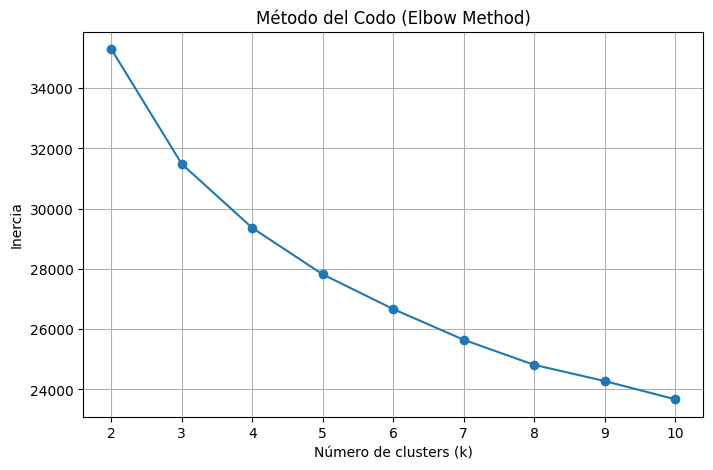

In [60]:
# -------------------------------------------------------------
# 8.1. Método del codo (Elbow Method)
# -------------------------------------------------------------

# Probamos distintos valores de k para ver cuál minimiza la inercia sin sobreajustar. Normalmente entre 2 y 10 es suficiente.

inertias = []
K = range(2, 11)   # probamos k de 2 a 10

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)   # guardamos la inercia

# Gráfico del método del codo
plt.figure(figsize=(8,5))
plt.plot(K, inertias, marker='o')
plt.title("Método del Codo (Elbow Method)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.grid(True)
plt.savefig("src/img/elbow_method.png", dpi=300, bbox_inches="tight") # Guardar la figura con alta resolución
plt.show() # Mostrar la figura en pantalla

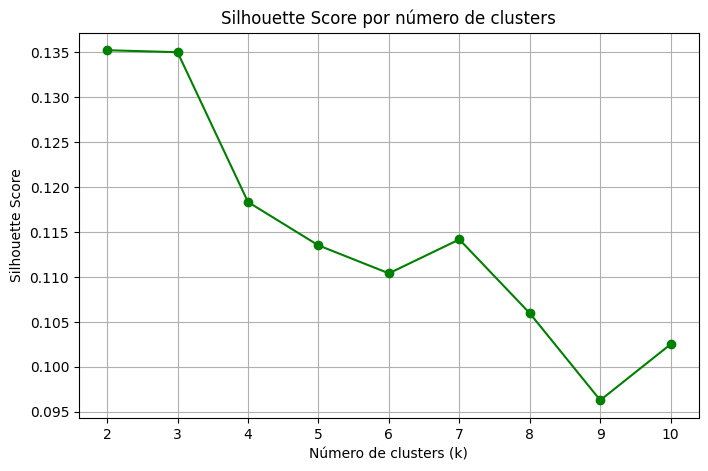

In [61]:
# -------------------------------------------------------------
# 8.2. Silhouette Score para validar k
# -------------------------------------------------------------

# El silhouette mide qué tan separados están los clusters.
# Valores cercanos a 1 indican clusters bien definidos.

sil_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    sil = silhouette_score(X_cluster, labels)
    sil_scores.append(sil)

# Gráfico del silhouette
plt.figure(figsize=(8,5))
plt.plot(K, sil_scores, marker='o', color='green')
plt.title("Silhouette Score por número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.savefig("src/img/silhouette_scores.png", dpi=300, bbox_inches="tight") # Guardar la figura con alta resolución
plt.show() # Mostrar la figura en pantalla

In [62]:
# -------------------------------------------------------------
# 8.3. Entrenamiento final del modelo KMeans
# -------------------------------------------------------------

# Elegimos el k óptimo según el elbow + silhouette.
# (Se puede ajustar este valor según gráficos)

k_optimo = 2   # según el Silhouette Score (podría ajustarse también a 3 según el elbow)

# Entrenamos el modelo final
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster)

# -------------------------------------------------------------
# Asignar los clusters SOLO a las filas sin NaN
# -------------------------------------------------------------

# df_cluster tiene menos filas porque eliminamos NaNs (lag/diff)

# Usamos sus índices para asignar correctamente los clusters
df_feat.loc[df_cluster.index, "Cluster"] = cluster_labels

# -------------------------------------------------------------
# Guardar el modelo entrenado en src/models/
# -------------------------------------------------------------
import joblib
joblib.dump(kmeans_final, "src/models/model_kmeans.pkl")

['src/models/model_kmeans.pkl']

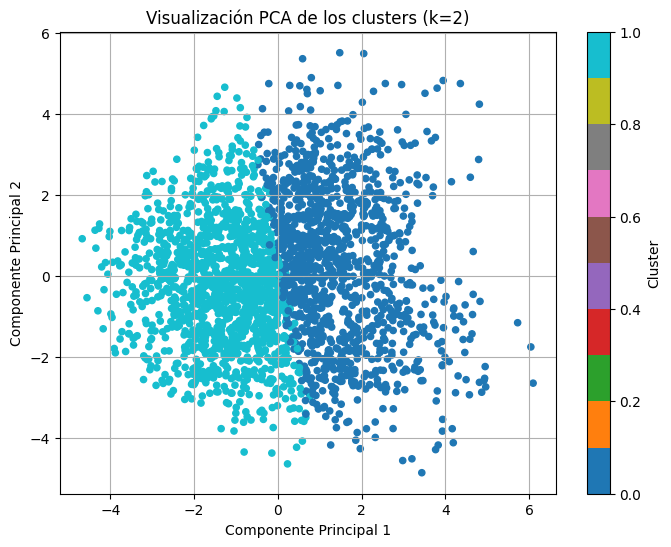

In [63]:
# -------------------------------------------------------------
# 8.4. Visualización 2D con PCA
# -------------------------------------------------------------

# Reducimos de 16 variables a 2 componentes principales para visualizar los clusters en un plano.

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap="tab10", s=20)
plt.title(f"Visualización PCA de los clusters (k={k_optimo})")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.savefig("src/img/pca_clusters.png", dpi=300, bbox_inches="tight") # Guardar la figura con alta resolución
plt.show() # Mostrar la figura en pantalla

In [64]:
# -------------------------------------------------------------
# 8.5. Interpretación básica de clusters
# -------------------------------------------------------------

# Calculamos la media de cada contaminante por cluster para entender qué caracteriza a cada grupo.

cluster_summary = df_feat.groupby("Cluster")[cols_numericas].mean()
cluster_summary

Contaminante,PM10,PM25,NO2,O3,PM10_roll7,PM25_roll7,NO2_roll7,O3_roll7,PM10_lag1,PM25_lag1,NO2_lag1,O3_lag1,PM10_diff,PM25_diff,NO2_diff,O3_diff
Cluster,,,,,,,,,,,,,,,,
0.0,23.605297,11.508709,21.401441,54.870198,22.643580,11.002085,21.143224,55.650920,23.885439,11.653759,21.816307,55.342535,-0.280142,-0.145051,-0.414866,-0.472338
1.0,13.951716,6.286242,17.238703,56.670022,14.892449,6.699360,17.390768,56.070433,13.722480,6.139383,16.821041,56.293455,0.229235,0.146859,0.417662,0.376567


In [65]:
# =============================================================
# 9. MODELOS DE REGRESIÓN
# =============================================================

# En este apartado entrenamos varios modelos para predecir PM10:
#   - Regresión Lineal
#   - Random Forest Regressor
#   - MLPRegressor (red neuronal)

# Evaluamos con: MAE, RMSE, R²

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

In [66]:
# -------------------------------------------------------------
# 9.1. Función auxiliar para evaluar modelos
# -------------------------------------------------------------

# Esta función calcula las métricas más importantes para evaluar un modelo de regresión:
#   - MAE  (Mean Absolute Error)
#   - RMSE (Root Mean Squared Error)
#   - R²   (Coeficiente de determinación)
#
# Además imprime los resultados de forma clara.

def evaluar_modelo(nombre, y_test, y_pred):
    # Error absoluto medio
    mae = mean_absolute_error(y_test, y_pred)

    # Error cuadrático medio y su raíz
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Coeficiente de determinación
    r2 = r2_score(y_test, y_pred)

    # Mostrar resultados
    print(f"\n===== {nombre} =====")
    print(f"MAE :  {mae:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"R²  :  {r2:.4f}")

    # Devolver métricas por si las necesitamos después
    return mae, rmse, r2

In [67]:
# -------------------------------------------------------------
# 9.2. Regresión Lineal
# -------------------------------------------------------------

# Entrenamos un modelo de regresión lineal simple para predecir PM10.
# Este modelo sirve como baseline (modelo base) para comparar con modelos más complejos como Random Forest o MLP.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------------------------------------
# Entrenar el modelo
# -------------------------------------------------------------

# Creamos el modelo de regresión lineal
modelo_lr = LinearRegression()

# Ajustamos el modelo usando los datos de entrenamiento
modelo_lr.fit(X_train, y_train)

# -------------------------------------------------------------
# Predicción sobre el conjunto de test
# -------------------------------------------------------------

y_pred_lr = modelo_lr.predict(X_test)

# -------------------------------------------------------------
# Evaluación del modelo (sin usar (sin usar evaluar_modelo, funcion definida en 8.1.)
# -------------------------------------------------------------

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

print("===== Regresión Lineal =====")
print("MAE : ", round(mae_lr, 4))
print("RMSE:", round(rmse_lr, 4))
print("R²  :", round(r2_lr, 4))

# -------------------------------------------------------------
# Guardar el modelo entrenado en src/models/
# -------------------------------------------------------------
import joblib
joblib.dump(modelo_lr, "src/models/model_regresion_lineal.pkl")


===== Regresión Lineal =====
MAE :  7.2434
RMSE: 9.0644
R²  : 0.0716


['src/models/model_regresion_lineal.pkl']

In [68]:
# -------------------------------------------------------------
# 9.2.1. Evaluación Regresión Lineal
# -------------------------------------------------------------

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Entrenar modelo
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

# Predicciones
y_pred_train = modelo_lr.predict(X_train)
y_pred_test = modelo_lr.predict(X_test)

# Métricas
def evaluar(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

mae_train, rmse_train, r2_train = evaluar(y_train, y_pred_train)
mae_test, rmse_test, r2_test = evaluar(y_test, y_pred_test)

print("===== Regresión Lineal =====")
print("---- TRAIN ----")
print("MAE :", round(mae_train, 4))
print("RMSE:", round(rmse_train, 4))
print("R²  :", round(r2_train, 4))

print("\n---- TEST ----")
print("MAE :", round(mae_test, 4))
print("RMSE:", round(rmse_test, 4))
print("R²  :", round(r2_test, 4))

===== Regresión Lineal =====
---- TRAIN ----
MAE : 7.0902
RMSE: 8.849
R²  : 0.0612

---- TEST ----
MAE : 7.2434
RMSE: 9.0644
R²  : 0.0716


In [69]:
# -------------------------------------------------------------
# 9.3. Random Forest Regressor
# -------------------------------------------------------------

modelo_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

mae_rf, rmse_rf, r2_rf = evaluar_modelo("Random Forest", y_test, y_pred_rf)

# -------------------------------------------------------------
# Guardar el modelo entrenado en src/models/
# -------------------------------------------------------------

joblib.dump(modelo_rf, "src/models/model_random_forest.pkl")



===== Random Forest =====
MAE :  5.3902
RMSE:  7.1171
R²  :  0.4277


['src/models/model_random_forest.pkl']

In [70]:
# -------------------------------------------------------------
# 9.4. MLPRegressor (Red Neuronal)
# -------------------------------------------------------------

modelo_mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

modelo_mlp.fit(X_train, y_train)
y_pred_mlp = modelo_mlp.predict(X_test)

mae_mlp, rmse_mlp, r2_mlp = evaluar_modelo("MLPRegressor", y_test, y_pred_mlp)

# -------------------------------------------------------------
# Guardar el modelo entrenado en src/models/
# -------------------------------------------------------------

joblib.dump(modelo_mlp, "src/models/model_mlp.pkl")


===== MLPRegressor =====
MAE :  7.3286
RMSE:  9.3599
R²  :  0.0101


c:\Users\maria\tf_env\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


['src/models/model_mlp.pkl']

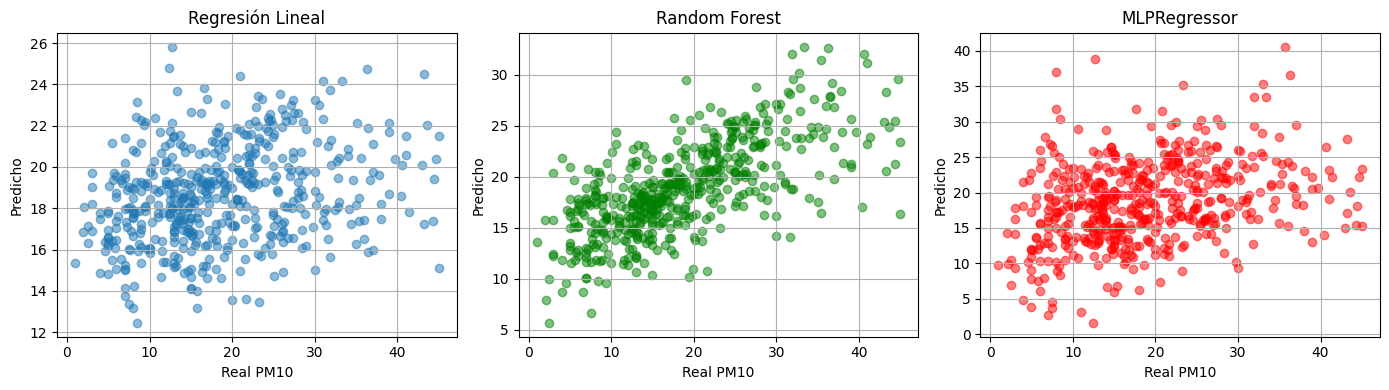

In [71]:
# -------------------------------------------------------------
# 9.5. Gráficas de predicción vs real
# -------------------------------------------------------------

plt.figure(figsize=(14,4))

# Lineal
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.xlabel("Real PM10")
plt.ylabel("Predicho")
plt.title("Regresión Lineal")
plt.grid(True)

# Random Forest
plt.subplot(1,3,2)
plt.scatter(y_test, y_pred_rf, alpha=0.5, color="green")
plt.xlabel("Real PM10")
plt.ylabel("Predicho")
plt.title("Random Forest")
plt.grid(True)

# MLP
plt.subplot(1,3,3)
plt.scatter(y_test, y_pred_mlp, alpha=0.5, color="red")
plt.xlabel("Real PM10")
plt.ylabel("Predicho")
plt.title("MLPRegressor")
plt.grid(True)

plt.tight_layout()
plt.savefig("src/img/prediccion_vs_real.png", dpi=300, bbox_inches="tight") # Guardar la figura con alta resolución
plt.show() # Mostrar la figura en pantalla

In [72]:
# -------------------------------------------------------------
# 9.6. Comparación final de modelos
# -------------------------------------------------------------

resultados = {
    "Modelo": ["Lineal", "Random Forest", "MLP"],
    "MAE": [mae_lr, mae_rf, mae_mlp],
    "RMSE": [rmse_lr, rmse_rf, rmse_mlp],
    "R2": [r2_lr, r2_rf, r2_mlp]
}

import pandas as pd
df_resultados = pd.DataFrame(resultados)
df_resultados

,Modelo,MAE,RMSE,R2
0,Lineal,7.243383,9.064412,0.071612
1,Random Forest,5.390165,7.117088,0.427659
2,MLP,7.328567,9.359878,0.010102
